In [4]:
import pandas as pd
import numpy as np

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'
df = pd.read_csv(url, header = None)

headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

df.columns = headers    
df.replace('?', np.nan, inplace=True)

avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("Average of normalized-losses:", avg_norm_loss)
df["normalized-losses"] = df["normalized-losses"].replace(np.nan, avg_norm_loss)

avg_bore = df["bore"].astype("float").mean(axis=0)
print("Average of bore:", avg_bore)
df["bore"] = df["bore"].replace(np.nan, avg_bore)

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['peak-rpm'] = pd.to_numeric(df['peak-rpm'], errors='coerce')

'''
missing_data = df.isnull()
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")    
'''
df.head()
df['num-of-doors'].value_counts()#.idxmax()

df_test = df[["drive-wheels", "body-style", "price"]]

df_grp = df_test.groupby(["drive-wheels", "body-style"], as_index=False).mean()
df_pivot = df_grp.pivot(index='drive-wheels', columns='body-style')
df_pivot

Average of normalized-losses: 122.0
Average of bore: 3.3297512437810943


price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

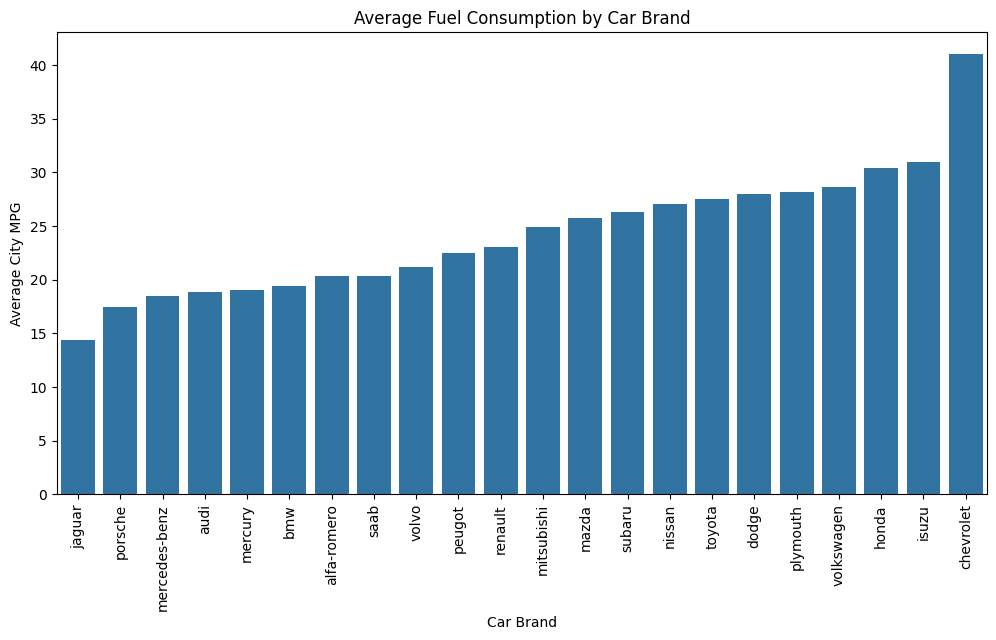

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert city-mpg to numeric
df["city-mpg"] = pd.to_numeric(df["city-mpg"])

# Average city mileage by brand
avg_mpg = df.groupby("make")["city-mpg"].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=avg_mpg.index, y=avg_mpg.values)

plt.xticks(rotation=90)
plt.xlabel("Car Brand")
plt.ylabel("Average City MPG")
plt.title("Average Fuel Consumption by Car Brand")
plt.show()
%matplotlib inline

(0.0, 53387.97875520015)

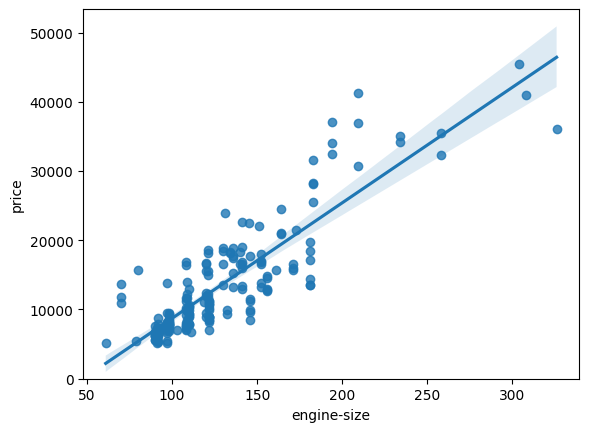

In [10]:
sns.regplot(x='engine-size', y='price', data=df)
plt.ylim(0,)

(0.0, 48154.69024965196)

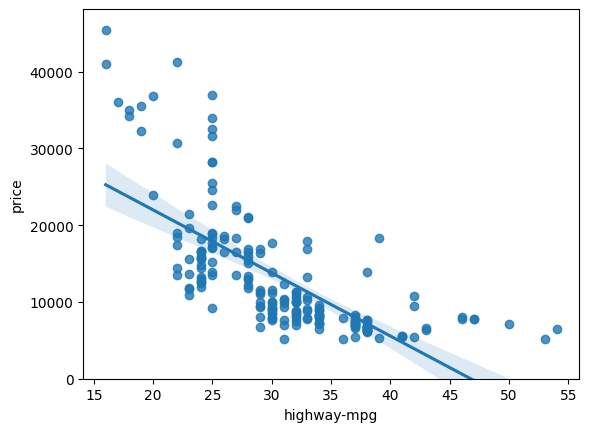

In [11]:
sns.regplot(x='highway-mpg', y='price', data=df)
plt.ylim(0,)

(0.0, 47414.1)

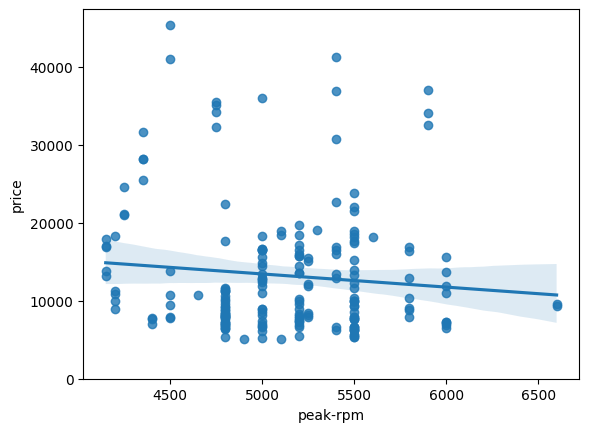

: 

In [ ]:
sns.regplot(x='peak-rpm', y='price', data=df)
plt.ylim(0,)

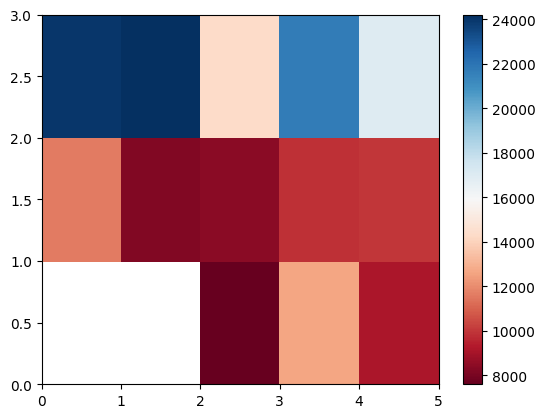

In [9]:
plt.pcolor(df_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

In [1]:
y=df["price"]
x=df["engine-size"]
plt.scatter(x,y)

plt.title("Scatter Plot of Engine Size")
plt.ylabel("Price")
plt.xlablel("Engine Size")

NameError: name 'df' is not defined

<Axes: xlabel='drive-wheels', ylabel='price'>

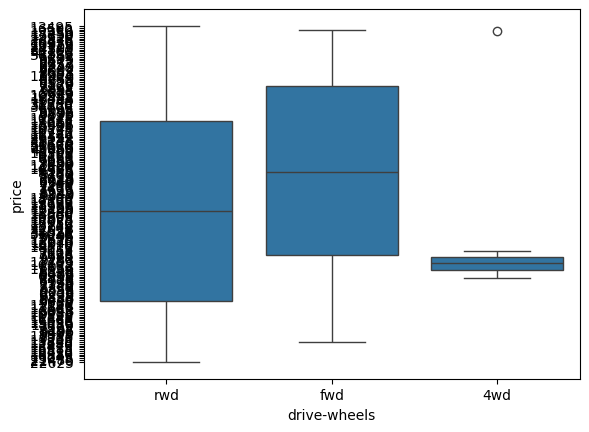

In [3]:
sns.boxplot(x = "drive-wheels", y = "price", data=df)

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="make", order=df["make"].value_counts().index)

plt.xticks(rotation=90)
plt.xlabel("Car Brand")
plt.ylabel("Number of Models")
plt.title("Brandwise Car Models")

plt.show()

Cheat Sheet: Exploratory Data Analysis
Package/Method

Description

Code Example

Complete dataframe correlation

Correlation matrix created using all the attributes of the dataset.

1 df.corr()

Specific Attribute correlation

Correlation matrix created using specific attributes of the dataset.

1 df[['attribute1','attribute2',...]].corr()

Scatter Plot

Create a scatter plot using the data points of the dependent variable along the x-axis and the independent variable along the y-axis.

 

from matlplotlib import pyplot as plt 

plt.scatter(df[['attribute_1']],df[['attribute_2']])


  

Regression Plot

Uses the dependent and independent variables in a Pandas data frame to create a scatter plot with a generated linear regression line for the data.

import seaborn as sns 

sns.regplot(x='attribute_1',y='attribute_2', data=df)

Box plot

Create a box-and-whisker plot that uses the pandas dataframe, the dependent, and the independent variables.

import seaborn as sns 

sns.boxplot(x='attribute_1',y='attribute_2', data=df)

Grouping by attributes

Create a group of different attributes of a dataset to create a subset of the data.

1 df_group = df[['attribute_1','attribute_2',...]]

GroupBy statements

a. Group the data by different categories of an attribute, displaying the average value of numerical attributes with the same category.b. Group the data by different categories of multiple attributes, displaying the average value of numerical attributes with the same category.

a) df_group = df.groupby(['attribute_1'],as_index=False).mean() 

b) df_group = df.groupby(['attribute_1','attribute_2'],as_index=False).mean()

Pivot Tables

Create Pivot tables for better representation of data based on parameters

1 grouped_pivot = df_group.pivot(index='attribute_1',columns='attribute_2')

Pseudocolor plot

Create a heatmap image using a PsuedoColor plot (or pcolor) using the pivot table as data.

from matlplotlib import pyplot as plt 

plt.pcolor(grouped_pivot, cmap='RdBu')

Pearson Coefficient and p-value

Calculate the Pearson Coefficient and p-value of a pair of attributes

From scipy import stats 

pearson_coef,p_value=stats.pearsonr(df['attribute_1'],df['attribute_2'])



In [9]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Step 1: Convert to numeric (important for IBM dataset style data)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['highway-mpg'] = pd.to_numeric(df['highway-mpg'], errors='coerce')

# Step 2: Remove rows with NaN in either column
df_clean = df[['highway-mpg', 'price']].dropna()

# Step 3: Define X and y
x = df_clean[['highway-mpg']]
y = df_clean['price']

# Step 4: Fit model
lm = LinearRegression()
lm.fit(x, y)

# Optional: check results
print("Slope:", lm.coef_[0])
print("Intercept:", lm.intercept_)

z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg' ] ]
lm.fit(z, df['price'])
Yhat = lm.predict(x)

Slope: -821.7333783219254
Intercept: 38423.3058581574


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

pr = PolynomialFeatures(degree=2)
pr.fit_transform([1,2])

ValueError: Expected 2D array, got 1D array instead:
array=[1 2].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [18]:
from sklearn.preprocessing import StandardScaler

SCALE=StandardScaler ()
SCALE. fit (x_data[ ['horsepower', 'highway-mpg' ] ] )

x_scale=SCALE.transform(x_data[ ['horsepower', 'highway-mpg' ] ] )

NameError: name 'x_data' is not defined

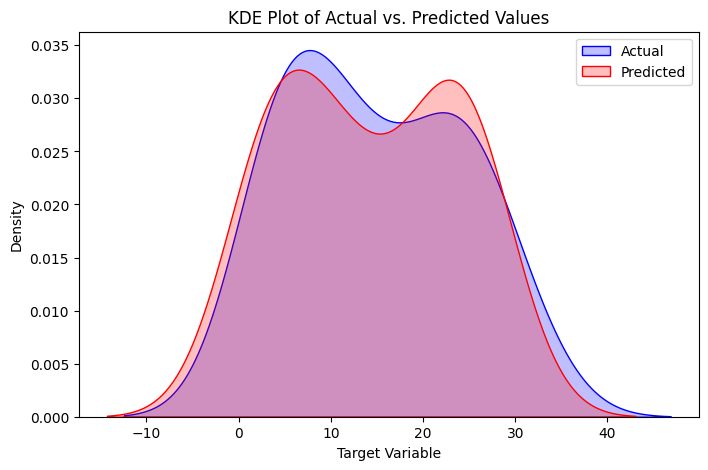

In [19]:
import numpy as npy
import pandas as pds
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Generating Sample Data
npy.random.seed(42)
x = npy.random.rand(100) * 10
y = 3 * x + npy.random.normal(0, 3, 100)  # Linear relation with noise
data = pds.DataFrame({'X': x, 'Y': y})

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(data[['X']], data['Y'], test_size=0.2, random_state=42)

# Training a Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Plotting KDE for Observed vs. Predicted Values
plt.figure(figsize=(8, 5))
sns.kdeplot(y_test, label='Actual', fill=True, color='blue')
sns.kdeplot(y_pred, label='Predicted', fill=True, color='red')
plt.xlabel('Target Variable')
plt.ylabel('Density')
plt.title('KDE Plot of Actual vs. Predicted Values')
plt.legend()
plt.show()